>
> # Scenario analysis
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *
from plot_func import *

In [2]:
# Enter variable and data type
variable = {"name": "base", "sym": "$A$", "int": False}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variable)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variable)

In [4]:
# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [5]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(10)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,35,80.407565,35,193.213563,35,True
1,48,79.372193,21,242.668617,48,True
2,19,89.451480,36,202.520007,36,True
3,26,96.117268,39,210.635806,39,True
4,27,92.009076,23,219.360354,27,True


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 5/1 for scenario 75000.0


In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [9]:
res_scn.dem.requests.loc[0] / res_scn.dem.inform.loc[0]
res_scn.sup.particip.loc[0] / res_scn.sup.regist.loc[0]
res_scn.dem.requests.loc[0]

75000.0    224.6
Name: 0, dtype: float64

In [10]:
eql_scn.dem.requests / 75000

scenario
75000.0    0.02199
Name: requests, dtype: float64

In [11]:
eql_scn.plf

,plat_profit
75000.0,3974.870265


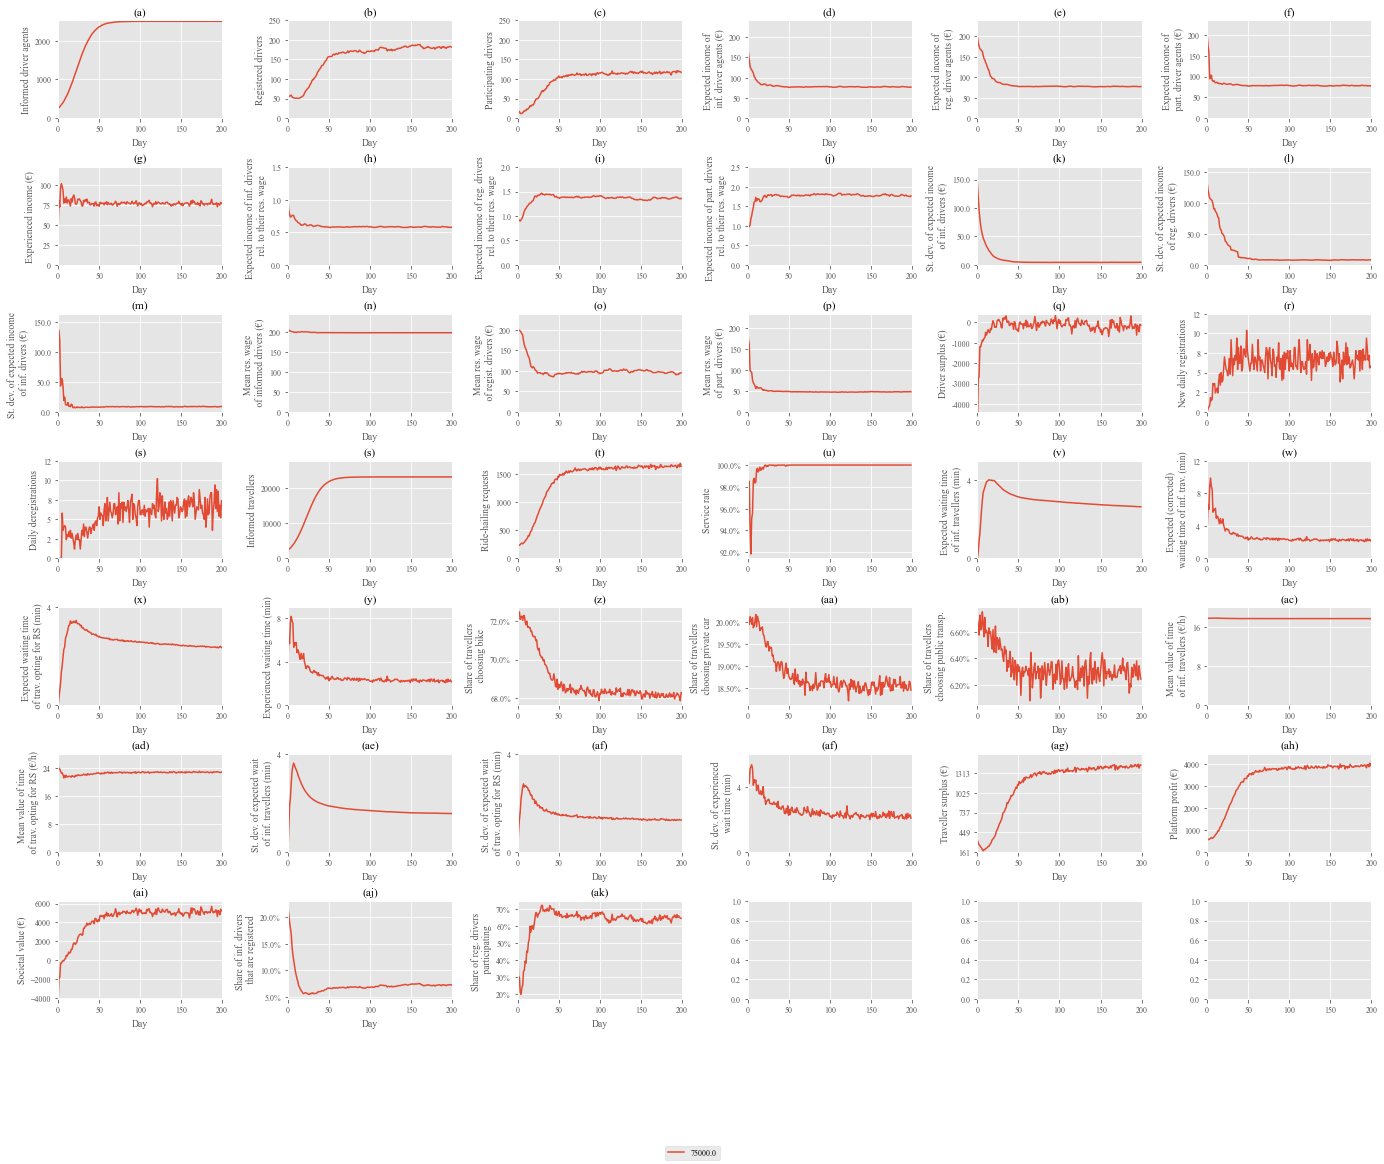

In [12]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

In [13]:
TINY_SIZE = 12
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=TINY_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

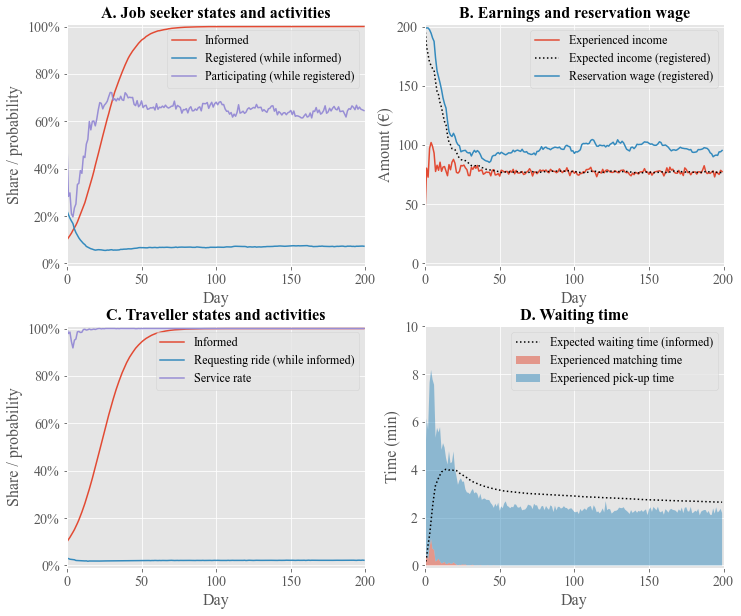

In [55]:
fig, axes = plt.subplots(2, 2, figsize = [12,10])
fig.subplots_adjust(hspace=.25, wspace=0.2, left=.12, right=.88)

axes[0, 0].plot(res_scn.sup.inform / 2500)
axes[0, 0].plot(res_scn.sup.regist / res_scn.sup.inform)
axes[0, 0].plot(res_scn.sup.particip / res_scn.sup.regist)
# axes[0, 0].plot(res_scn.sup.share_idle_time)
axes[0, 0].set_ylabel('Share / probability')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('A. Job seeker states and activities', weight='bold',fontsize=16)
axes[0, 0].set_xlim(left = 0, right = 200)
axes[0, 0].set_ylim(bottom = -0.01, top = 1.01)
axes[0, 0].legend(['Informed','Registered (while informed)','Participating (while registered)'])
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[0, 1].plot(res_scn.sup.mean_exp_inc)
axes[0, 1].plot(res_scn.sup.mean_perc_inc_reg,linestyle=':',color='k')
# axes[0, 1].plot(res_scn.sup.std_exp_inc)
# axes[0, 1].plot(res_scn.sup.std_perc_inc)
axes[0, 1].plot(res_scn.sup.res_wage_reg)
# axes[0, 1].plot(res_scn.sup.res_wage_ptcp)
axes[0, 1].set_ylabel('Amount (€)')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('B. Earnings and reservation wage', weight='bold',fontsize=16)
axes[0, 1].set_xlim(left = 0, right = 200)
axes[0, 1].set_ylim(bottom = -2, top = 202)
axes[0, 1].legend(['Experienced income','Expected income (registered)','Reservation wage (registered)','Reservation wage (participating)'])

axes[1, 0].plot(res_scn.dem.inform / res_scn.dem.inform.max())
# axes[1, 0].plot(res_scn.dem.requests / 75000)
axes[1, 0].plot(res_scn.dem.requests / (res_scn.dem.inform * 75000 / res_scn.dem.inform.max()))
axes[1, 0].plot(res_scn.dem.gets_offer)
axes[1, 0].set_ylabel('Share / probability')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('C. Traveller states and activities', weight='bold',fontsize=16)
axes[1, 0].set_xlim(left = 0, right = 200)
axes[1, 0].set_ylim(bottom = -0.01, top = 1.01)
axes[1, 0].legend(['Informed','Requesting ride (while informed)','Service rate'], loc='upper right')
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# axes[1, 1].plot(res_scn.dem.mean_wait)
# axes[1, 1].plot(res_scn.dem.match_time)
# axes[1, 1].plot(res_scn.dem.pickup_time)
df = res_scn.dem['match_time'][75000].copy().to_frame(name='match_time')
df['pickup_time'] = res_scn.dem['pickup_time'][75000]
df[df < 0] = 0
x = range(0,200)
y1 = df['match_time'] / 60
y2 = df['pickup_time'] / 60
axes[1, 1].stackplot(x,y1,y2, alpha=0.5)
axes[1, 1].plot(res_scn.dem.perc_wait/60, linestyle=':',color='k')
# axes[1, 1].plot(res_scn.dem.perc_wait_req, linestyle='-')
# axes[1, 1].plot(res_scn.dem.std_exp_wait)
# axes[1, 1].plot(res_scn.dem.std_perc_wait)
# axes[1, 1].plot(res_scn.dem.vot_req, linestyle=':')
axes[1, 1].set_ylabel('Time (min)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('D. Waiting time', weight='bold',fontsize=16)
axes[1, 1].set_xlim(left = 0, right = 200)
axes[1, 1].set_ylim(bottom = -0.1, top =10)
axes[1, 1].legend(['Expected waiting time (informed)','Experienced matching time','Experienced pick-up time'])

handles, labels = plt.gca().get_legend_handles_labels()

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'evo.jpg'),dpi=300,bbox_inches='tight')

In [56]:
res_scn.dem.requests / (res_scn.dem.inform * 75000 / res_scn.dem.inform.max())

,75000.0
day,
0,0.029960
1,0.028965
2,0.026205
3,0.025359
4,0.024896
...,...
195,0.022013
196,0.022075
197,0.021637


In [15]:
# res_scn.dem['match_time']
df

,match_time,pickup_time
day,,
0,0.873643,234.288125
1,27.855780,340.822881
2,14.858749,325.381230
3,45.294974,412.981744
4,66.394035,424.023823
...,...,...
195,0.000000,145.782868
196,0.000000,132.945245
197,0.000000,136.063232


In [16]:
(res_scn.dem.requests / res_scn.dem.inform).head(10)
(res_scn.sup.regist / res_scn.sup.inform).head(25)
(res_scn.sup.particip / res_scn.sup.regist).head(25)
micro.dem.perc_wait[0] * micro.dem.requests[0]
micro.dem.requests[0][micro.dem.requests[0] == False] = np.nan

In [17]:
# fig, axes = plt.subplots(1, 2, figsize = [10,4])
# fig.subplots_adjust(hspace=.2, wspace=0.25, left=.12, right=.88)
# # fig.suptitle('Heterogeneity in main performance indicators', fontsize=16, weight='bold')

# micro.sup.exp_inc[0]['199'].loc[micro.sup.exp_inc[0]['199'] >= 0].hist(bins=50,density=True,alpha=0.5,ax=axes[0],label='Experienced')
# micro.sup.perc_inc[0]['199'].loc[micro.sup.perc_inc[0]['199'] >= 0].hist(bins=50,density=True,alpha=0.5,ax=axes[0], label='Expected')
# axes[0].set_xlabel("Daily earnings (€)")
# axes[0].set_xlim([0,150])
# axes[0].set_ylabel("Density")
# axes[0].set_title("A. Job seekers",weight='bold')
# axes[0].legend()

# micro.dem.wait_time[0]['199'].loc[micro.dem.wait_time[0]['199'] >= 0].hist(bins=100,density=True,alpha=0.5,ax=axes[1], label='Experienced')
# micro.dem.perc_wait[0]['199'].loc[micro.dem.perc_wait[0]['199'] >= 0].hist(bins=100,density=True,alpha=0.5,ax=axes[1], label='Expected')
# abc = micro.dem.requests[0].copy()
# abc[abc == False] = np.nan
# micro.dem['perc_wait_req'][0] = micro.dem.perc_wait[0] * abc
# axes[1].set_xlabel("Waiting time (s)")
# axes[1].set_ylabel("Density")
# axes[1].set_xlim([0, 1000])
# axes[1].set_title("B. Travellers",weight='bold')
# axes[1].legend()
# # micro.dem.perc_wait_req[0]['199'].loc[micro.dem.perc_wait_req[0]['199'] >= 0].hist(bins=100,density=True,alpha=0.5,color='k')

In [18]:
# params[0]
micro.dem['perc_wait_req'][0]['199']

DotMap(_ipython_display_=DotMap(), _repr_mimebundle_=DotMap())

In [19]:
requests[0]

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike
pax_id,,,,,,,,,
0,896347548,442534806,2021-11-01 12:23:12,3189,2416.768969,25.246984,-3.510941,-5.823855,-1.775200
1,46429971,4837346311,2021-11-01 11:12:18,3532,2741.112123,10.522044,-2.566612,-3.250842,-0.821269
2,7890114045,413562329,2021-11-01 17:56:29,12254,3263.899637,15.252714,-4.173784,-1597.870518,-4.131367
3,46434000,46350260,2021-11-01 14:59:02,3574,2788.614898,34.284845,-4.207821,-6.383554,-2.706331
4,5833554542,7997475204,2021-11-01 12:50:36,4402,2309.962509,26.980868,-3.870012,-8.496503,-2.624939
...,...,...,...,...,...,...,...,...,...
23258,2311089897,46427652,2021-11-01 09:20:26,2763,2285.514700,10.128432,-3.637799,-2.884601,-0.618104
23259,1673410150,46329158,2021-11-01 12:21:45,3350,2508.837747,14.445231,-2.810218,-3.507253,-1.069990
23260,46275357,2012191567,2021-11-01 13:36:23,2976,2065.121926,11.910865,-2.587919,-2.563650,-0.782186


In [20]:
# %load_ext autoreload
# %autoreload 2
# import os, sys # add MaaSSim and MaaSSim/MaaSSim to path (not needed if already in path)
# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)
# params[0]

In [21]:
import osmnx as ox #OSM download and parse
G = ox.graph_from_place('Amsterdam, Netherlands', network_type='drive')

In [22]:
# loads graph and skim from a params paths
# if set_t:
#     _params = set_t0(_params)
skim_csv = 'C:\\Users\\arjanderuijter\\Programming\\MaaSSim\\data\\graphs\\Amsterdam.csv'

# _inData.G = ox.load_graphml(params[0].paths.G)
nodelos = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
skim = pd.read_csv(skim_csv, index_col='Unnamed: 0')
skim.columns = [int(c) for c in skim.columns]
# _inData.skim = skim
# _inData
skim

,6316199,46379627,46380013,46380094,46372441,46389218,46380483,46372472,46388842,46380482,...,439663488,46562430,46583853,1739504416,433807091,46571771,46581921,46540815,46540740,7890114045
6316199,0,42,86,123,206,225,233,244,267,273,...,14207,14233,14285,14345,14407,14803,15061,15254,15270,15680
25596477,4254,4212,4256,4293,4376,3948,4403,4414,3990,4443,...,16018,16044,16096,16156,16218,16614,16872,17065,17081,17491
25658579,4425,4467,4359,4397,4230,4650,4494,4268,4639,4534,...,16867,16894,16945,17006,17068,17464,17722,17914,17931,18341
26203121,2377,2419,2311,2348,2182,2406,2165,2220,2364,2205,...,12978,13004,13056,13117,13179,13575,13833,14025,14041,14451
26206556,2064,2106,1998,2036,1869,2218,1852,1907,2176,1892,...,13958,13985,14036,14097,14159,14555,14813,15005,15022,15432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8378814666,6450,6493,6384,6422,6256,6493,6520,6293,6535,6559,...,18563,18590,18641,18702,18764,19160,19418,19610,19627,20037
8378814667,6433,6475,6367,6404,6238,6475,6502,6276,6517,6542,...,18546,18572,18624,18684,18746,19142,19400,19592,19609,20019
8378814668,6481,6523,6415,6453,6286,6524,6550,6324,6566,6590,...,18594,18620,18672,18732,18794,19190,19448,19641,19657,20067
8378814669,6465,6508,6400,6437,6271,6508,6535,6309,6550,6575,...,18578,18605,18656,18717,18779,19175,19433,19625,19642,20052


In [23]:
# from moduleutils import load_G
# inData = load_G(inData, params[0], stats=True, set_t=False)  # download graph for the 'params.city' and calc the skim matrices

In [24]:
# # abc = os.path.abspath(os.path.join('maassim\\utils.py'))
# abc = 'C:\\Users\\arjanderuijter\\Programming\\MaaSSim\\maassim\\utils.py'
# abc
# from abc import load_G

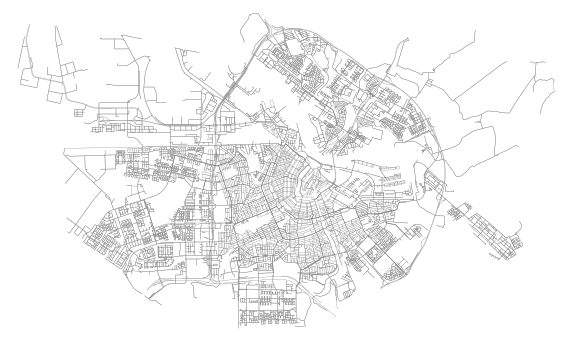

In [25]:
_ = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_linewidth=0.3,
                            show=False, close=False,
                            edge_color='grey', bgcolor='white')

In [26]:
import networkx as nx

In [27]:
abc = requests[0].copy()
abc['wait_time_195'] = micro.dem['wait_time'][0]['199']
abc['wait_time_196'] = micro.dem['wait_time'][0]['199']
abc['wait_time_197'] = micro.dem['wait_time'][0]['199']
abc['wait_time_198'] = micro.dem['wait_time'][0]['199']
abc['wait_time_199'] = micro.dem['wait_time'][0]['199']
abc['wait_time'] = abc[['wait_time_195','wait_time_196','wait_time_197','wait_time_198','wait_time_199']].mean(axis=1)
abc['perc_wait'] = micro.dem['perc_wait'][0]['199']
abc
# abc[['wait_time_195','wait_time_196','wait_time_197','wait_time_198','wait_time_199']]

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike,wait_time_195,wait_time_196,wait_time_197,wait_time_198,wait_time_199,wait_time,perc_wait
pax_id,,,,,,,,,,,,,,,,
0,896347548,442534806,2021-11-01 12:23:12,3189,2416.768969,25.246984,-3.510941,-5.823855,-1.775200,NaN,NaN,NaN,NaN,NaN,NaN,308.593140
1,46429971,4837346311,2021-11-01 11:12:18,3532,2741.112123,10.522044,-2.566612,-3.250842,-0.821269,NaN,NaN,NaN,NaN,NaN,NaN,94.311798
2,7890114045,413562329,2021-11-01 17:56:29,12254,3263.899637,15.252714,-4.173784,-1597.870518,-4.131367,0.0,0.0,0.0,0.0,0.0,0.0,464.776276
3,46434000,46350260,2021-11-01 14:59:02,3574,2788.614898,34.284845,-4.207821,-6.383554,-2.706331,NaN,NaN,NaN,NaN,NaN,NaN,75.434700
4,5833554542,7997475204,2021-11-01 12:50:36,4402,2309.962509,26.980868,-3.870012,-8.496503,-2.624939,NaN,NaN,NaN,NaN,NaN,NaN,70.605598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23258,2311089897,46427652,2021-11-01 09:20:26,2763,2285.514700,10.128432,-3.637799,-2.884601,-0.618104,NaN,NaN,NaN,NaN,NaN,NaN,65.938927
23259,1673410150,46329158,2021-11-01 12:21:45,3350,2508.837747,14.445231,-2.810218,-3.507253,-1.069990,NaN,NaN,NaN,NaN,NaN,NaN,228.490433
23260,46275357,2012191567,2021-11-01 13:36:23,2976,2065.121926,11.910865,-2.587919,-2.563650,-0.782186,NaN,NaN,NaN,NaN,NaN,NaN,130.227859


In [28]:
micro.sup.perc_inc[0]
micro.sup.regist[0]
df_regist = micro.sup.regist[0].copy()
df_regist[df_regist == False] = np.nan
df_perc_inc_reg = micro.sup.perc_inc[0] * df_regist
df_perc_inc_reg.head(20)

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
veh,,,,,,,,,,,,,,,,,,,,,
1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
bc = abc.groupby('origin', as_index=True)['wait_time'].mean()
bc = pd.DataFrame(bc)
cd = abc.groupby('origin', as_index=True)['perc_wait'].mean()
cd = pd.DataFrame(cd)

In [30]:
defg = drivers[0].copy()
defg['exp_inc'] = micro.sup['exp_inc'][0]['199']
defg['perc_inc'] = micro.sup['perc_inc'][0]['199']
df_2 = defg.groupby('pos', as_index=True)['exp_inc'].mean()
df_2 = pd.DataFrame(df_2)
df_3 = defg.groupby('pos', as_index=True)['perc_inc'].mean()
df_3 = pd.DataFrame(df_3)

In [31]:
node_list = list(G.nodes())
# nodes = G.nodes().to_numpy()
xyz = pd.DataFrame(index=node_list)
xyz['wait_time'] = np.nan
xyz.update(bc)
xyz[xyz['wait_time'] >= 0]
xyz = xyz['wait_time'].to_dict()
zab = pd.DataFrame(index=node_list)
zab['perc_wait'] = np.nan
zab.update(cd)
zab[zab['perc_wait'] >= 0]
zab = zab['perc_wait'].to_dict()
dfje = pd.DataFrame(index=node_list)
dfje['exp_wait'] = np.nan
dfje.update(df_2)
dfje = dfje.to_dict()
dfje_2 = pd.DataFrame(index=node_list)
dfje_2['perc_wait'] = np.nan
dfje_2.update(df_3)
dfje_2 = dfje_2.to_dict()

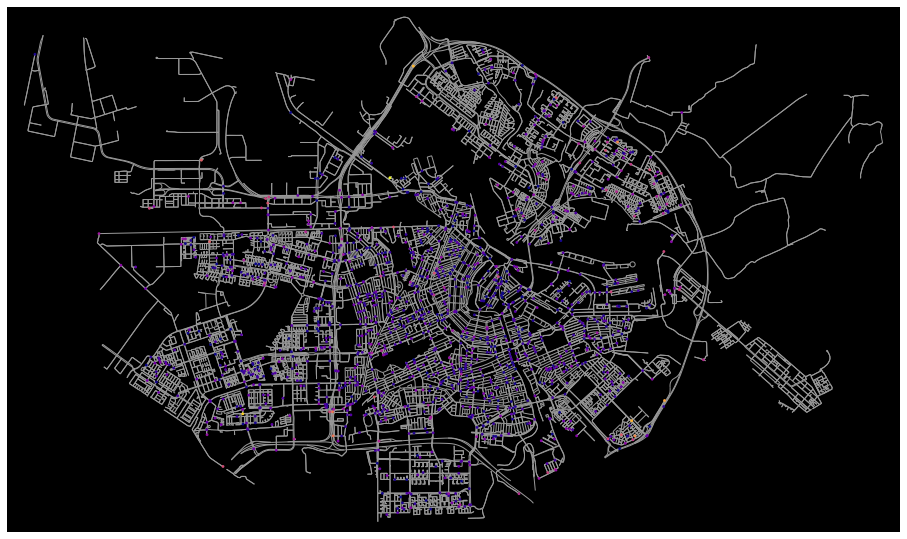

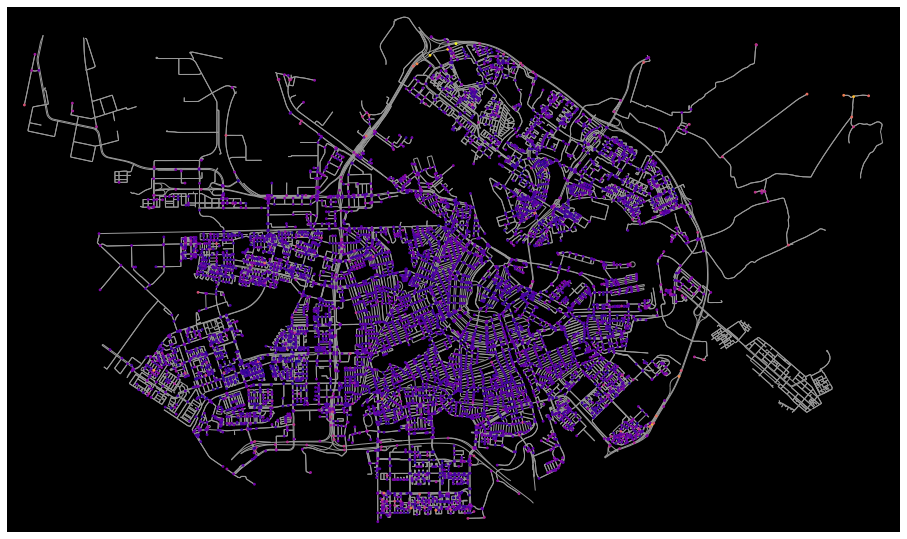

In [32]:
# calculate node betweenness centrality, weighted by travel time
# bc = nx.betweenness_centrality(D, weight="travel_time", normalized=True)
nx.set_node_attributes(G, values=xyz, name="bc")

# plot the graph, coloring nodes by betweenness centrality
nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="plasma")
fig, ax = ox.plot_graph(
    G, bgcolor="k", node_color=nc, node_size=8, edge_linewidth=1, figsize=(16, 16))


nx.set_node_attributes(G, values=zab, name="cd")
nc = ox.plot.get_node_colors_by_attr(G, "cd", cmap="plasma")
fig, ax = ox.plot_graph(
    G, bgcolor="k", node_color=nc, node_size=8, edge_linewidth=1, figsize=(16, 16))

# nx.set_node_attributes(G, values=zab, name="dfje_2")
# nc = ox.plot.get_node_colors_by_attr(G, "cd", cmap="plasma")
# fig, ax = ox.plot_graph(
#     G, bgcolor="k", node_color=nc, node_size=8, edge_linewidth=1, figsize=(16, 16))

In [33]:
center_x = pd.DataFrame((G.nodes(data='x')))[1].mean()
center_y = pd.DataFrame((G.nodes(data='y')))[1].mean()

nearest = ox.distance.get_nearest_node(G, (center_y, center_x))

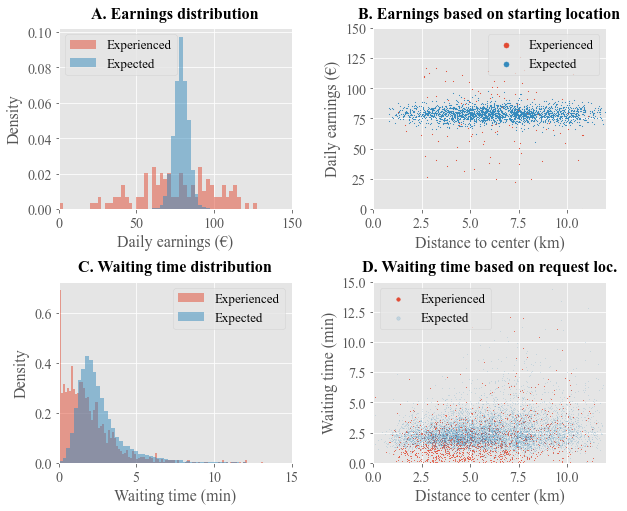

In [34]:
fig, axes = plt.subplots(2, 2, figsize = [10,8])
fig.subplots_adjust(hspace=.4, wspace=0.35, left=.12, right=.88)

# fig, axes = plt.subplots(1, 2, figsize = [10,4])
# fig.subplots_adjust(hspace=.2, wspace=0.25, left=.12, right=.88)
# fig.suptitle('Heterogeneity in main performance indicators', fontsize=16, weight='bold')

micro.sup.exp_inc[0]['199'].loc[micro.sup.exp_inc[0]['199'] >= 0].hist(bins=60,range=(0,150),density=True,alpha=0.5,ax=axes[0,0],label='Experienced')
micro.sup.perc_inc[0]['199'].loc[micro.sup.perc_inc[0]['199'] >= 0].hist(bins=60,range=(0,150),density=True,alpha=0.5,ax=axes[0,0], label='Expected')
# df_perc_inc_reg['199'].loc[df_perc_inc_reg['199'] >= 0].hist(bins=60,range=(0,150),density=True,alpha=0.5,ax=axes[0,0], label='Expected reg')
axes[0,0].set_xlabel("Daily earnings (€)")
axes[0,0].set_xlim([0,150])
axes[0,0].set_ylabel("Density")
axes[0,0].set_title("A. Earnings distribution",weight='bold', pad=10, fontsize=16)
axes[0,0].legend(fontsize=13)

(micro.dem.wait_time[0]['199'].loc[micro.dem.wait_time[0]['199'] >= 0] / 60).hist(bins=100,density=True,alpha=0.5,ax=axes[1,0], label='Experienced')
(micro.dem.perc_wait[0]['199'].loc[micro.dem.perc_wait[0]['199'] >= 0] / 60).hist(bins=100,density=True,alpha=0.5,ax=axes[1,0], label='Expected')
abc = micro.dem.requests[0].copy()
abc[abc == False] = np.nan
micro.dem['perc_wait_req'][0] = micro.dem.perc_wait[0] * abc
axes[1, 0].set_xlabel("Waiting time (min)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_xlim([0, 15])
axes[1, 0].set_title("C. Waiting time distribution",weight='bold', pad=10, fontsize = 16)
axes[1, 0].legend(fontsize=13)
# micro.dem.perc_wait_req[0]['199'].loc[micro.dem.perc_wait_req[0]['199'] >= 0].hist(bins=100,density=True,alpha=0.5,color='k')

df_2['pos'] = df_2.index
df_2['dist_cent'] = df_2['pos'].apply(lambda x: skim[x][nearest] / 1000)
# plt.scatter(df_2['dist_cent'],df_2['exp_inc'],s=0.2,alpha=1,label='Experienced',ax=axes[0])
axes[0, 1].scatter(df_2['dist_cent'],df_2['exp_inc'],s=0.4,alpha=1,label='Experienced')

df_3['pos'] = df_3.index
df_3['dist_cent'] = df_3['pos'].apply(lambda x: skim[x][nearest] / 1000)
axes[0, 1].scatter(df_3['dist_cent'],df_3['perc_inc'],s=0.4,alpha=1,label='Expected')
# plt.scatter(df_3['dist_cent'],df_3['perc_inc'],s=0.2,alpha=1,label='Expected',ax=axes[0])

bc['origin'] = bc.index
bc['dist_cent'] = bc['origin'].apply(lambda x: skim[x][nearest] / 1000)
axes[1, 1].scatter(bc['dist_cent'],bc['wait_time']/60,s=0.2,alpha=1,label='Experienced')

cd['origin'] = cd.index
cd['dist_cent'] = cd['origin'].apply(lambda x: skim[x][nearest] / 1000)
axes[1, 1].scatter(cd['dist_cent'],cd['perc_wait']/60,s=0.2,alpha=0.2,label='Expected')

axes[0, 1].set_xlabel('Distance to center (km)')
axes[0, 1].set_ylabel('Daily earnings (€)')
axes[0, 1].set_title('B. Earnings based on starting location', weight='bold', pad=10, fontsize=16)
axes[1, 1].set_ylabel('Waiting time (min)')
axes[1, 1].set_xlabel('Distance to center (km)')
axes[1, 1].set_title('D. Waiting time based on request loc.', weight='bold',pad=10, fontsize=16)
axes[1, 1].set_ylim(0,15)
axes[1, 1].set_xlim(0,12)
axes[0, 1].set_ylim(0,150)
axes[0, 1].set_xlim(0,12)
axes[0, 1].legend(markerscale=8, fontsize=13)
axes[1, 1].legend(markerscale=8, fontsize=13)

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'hetero.jpg'),dpi=300,bbox_inches='tight')

In [35]:
# eql_runs['sup'][75000]
eql_scn['sup'].loc[75000]
eql_scn['dem'].loc[75000].requests / 75000

0.021989866666666663

<AxesSubplot:>

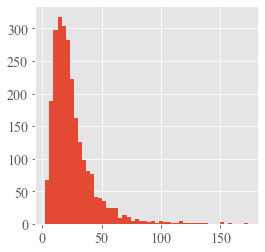

In [36]:
(drivers[0].res_wage / 8).hist(bins=50)

In [37]:
# Compute modal share
eql_scn.dem['tot_pt'] = eql_scn.dem['pt'] + eql_scn.dem['extra_pt']
eql_scn.dem['tot_bike'] = eql_scn.dem['bike'] + eql_scn.dem['extra_bike']
eql_scn.dem['tot_car'] = eql_scn.dem['car'] + eql_scn.dem['extra_car']
tot_req = eql_scn.dem['tot_pt'] + eql_scn.dem['tot_bike'] + eql_scn.dem['tot_car'] + eql_scn.dem['requests']
eql_scn.dem['requests'] / tot_req

scenario
75000.0    0.022489
dtype: float64

In [38]:
eql_scn.dem.loc[75000]

inform               23284.600000
requests              1649.240000
gets_offer               1.000000
accepts_offer         1649.240000
mean_wait              136.065578
corr_mean_wait         136.065578
perc_wait              158.801372
perc_wait_req          142.359255
bike                 15859.440000
car                   4315.400000
pt                    1460.520000
vot_inf                 17.710783
vot_req                 22.829619
std_perc_wait           94.408717
std_exp_wait           132.898021
std_corr_wait          132.898021
std_perc_wait_req       78.766009
cons_surplus          1424.941488
pickup_time            137.640020
match_time              -1.574441
corr_match_time               NaN
extra_bike           38299.400000
extra_pt              5032.600000
extra_car             6720.200000
tot_pt                6493.120000
tot_bike             54158.840000
tot_car              11035.600000
Name: 75000.0, dtype: float64

In [39]:
eql_scn.sup.loc[75000].particip / eql_scn.sup.loc[75000].regist

0.6512291483757683

In [40]:
requests[0]
dist_req = requests[0][micro.dem.requests[0]['199'] == 1]
# micro.dem.requests[0]['199']
dist_req['dist'].mean()

5392.32439176544

In [41]:
all_pax[0].head(50)

,pos,event,platforms,VoT,U_bike,U_car,U_pt,ASC_rs,mode_choice,prob_rs
0,896347548,travellerEvent.STARTS_DAY,[0],25.246984,-1.775200,-3.510941,-5.823855,-2.2497,day-to-day,0.118700
1,46429971,travellerEvent.STARTS_DAY,[0],10.522044,-0.821269,-2.566612,-3.250842,-2.2497,day-to-day,0.051776
2,7890114045,travellerEvent.STARTS_DAY,[0],15.252714,-4.131367,-4.173784,-1597.870518,-2.2497,day-to-day,0.058367
3,46434000,travellerEvent.STARTS_DAY,[0],34.284845,-2.706331,-4.207821,-6.383554,-2.2497,day-to-day,0.198203
4,5833554542,travellerEvent.STARTS_DAY,[0],26.980868,-2.624939,-3.870012,-8.496503,-2.2497,day-to-day,0.155187
5,46434153,travellerEvent.STARTS_DAY,[0],4.347276,-0.549824,-2.358972,-2.449157,-2.2497,bike,0.024429
6,46553810,travellerEvent.STARTS_DAY,[0],14.974856,-3.638907,-3.960251,-5.372357,-2.2497,day-to-day,0.054960
7,3649050877,travellerEvent.STARTS_DAY,[0],7.385780,-0.997811,-2.640857,-3.417016,-2.2497,bike,0.032357
8,46376939,travellerEvent.STARTS_DAY,[0],7.617496,-1.381137,-2.896182,-3.182657,-2.2497,bike,0.024908
9,46365231,travellerEvent.STARTS_DAY,[0],10.592782,-0.707339,-2.506983,-3.065671,-2.2497,day-to-day,0.053410


In [42]:
requests[0]

,origin,destination,treq,dist,haver_dist,VoT,U_car,U_pt,U_bike
pax_id,,,,,,,,,
0,896347548,442534806,2021-11-01 12:23:12,3189,2416.768969,25.246984,-3.510941,-5.823855,-1.775200
1,46429971,4837346311,2021-11-01 11:12:18,3532,2741.112123,10.522044,-2.566612,-3.250842,-0.821269
2,7890114045,413562329,2021-11-01 17:56:29,12254,3263.899637,15.252714,-4.173784,-1597.870518,-4.131367
3,46434000,46350260,2021-11-01 14:59:02,3574,2788.614898,34.284845,-4.207821,-6.383554,-2.706331
4,5833554542,7997475204,2021-11-01 12:50:36,4402,2309.962509,26.980868,-3.870012,-8.496503,-2.624939
...,...,...,...,...,...,...,...,...,...
23258,2311089897,46427652,2021-11-01 09:20:26,2763,2285.514700,10.128432,-3.637799,-2.884601,-0.618104
23259,1673410150,46329158,2021-11-01 12:21:45,3350,2508.837747,14.445231,-2.810218,-3.507253,-1.069990
23260,46275357,2012191567,2021-11-01 13:36:23,2976,2065.121926,11.910865,-2.587919,-2.563650,-0.782186


In [43]:
bc
# cd
micro.sup.keys()

odict_keys(['inform', 'regist', 'ptcp', 'perc_inc', 'exp_inc'])

In [44]:
res_scn.dem.keys()
# res_scn.sup.keys()

odict_keys(['inform', 'requests', 'gets_offer', 'accepts_offer', 'mean_wait', 'corr_mean_wait', 'perc_wait', 'perc_wait_req', 'bike', 'car', 'pt', 'vot_inf', 'vot_req', 'std_perc_wait', 'std_exp_wait', 'std_corr_wait', 'std_perc_wait_req', 'cons_surplus', 'pickup_time', 'match_time', 'corr_match_time', 'extra_bike', 'extra_pt', 'extra_car'])

<AxesSubplot:xlabel='day', ylabel='Volume of informed drivers'>

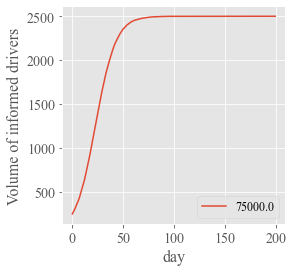

In [45]:
# Plot an individual indicator
plot_inform = res_scn.sup.inform.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [46]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
print(eql_scn.sup.astype('str').T.to_latex(index=True))
print(eql_scn.dem.astype('str').T.to_latex(index=True))
print(eql_scn.plf.astype('str').T.to_latex(index=True))

\begin{tabular}{ll}
\toprule
scenario &              75000.0 \\
\midrule
inform             &               2500.0 \\
regist             &   182.23999999999998 \\
particip           &   118.67999999999999 \\
mean\_perc\_inc      &    76.58800537165195 \\
mean\_perc\_inc\_ptcp &    77.72735792393192 \\
mean\_perc\_inc\_reg  &    76.92012138389381 \\
mean\_exp\_inc       &    76.99495405863145 \\
rel\_perc\_inc       &    0.577457852659536 \\
rel\_perc\_inc\_reg   &   1.3601821833814942 \\
rel\_perc\_inc\_ptcp  &   1.7544487101634487 \\
std\_perc\_inc       &    4.658127346038818 \\
std\_exp\_inc        &   25.562793731689453 \\
std\_perc\_inc\_reg   &     8.15753746438872 \\
std\_perc\_inc\_ptcp  &    8.459987004503699 \\
res\_wage\_inf       &    198.1898738714786 \\
res\_wage\_reg       &    93.30504828636224 \\
res\_wage\_ptcp      &    48.07708554097373 \\
new\_regist         &    6.640000000000001 \\
deregist           &                 6.68 \\
driver\_surplus     &  -233.802029994

In [47]:
# # Plot indicators for single scenario (e.g. base scenario)
# value = 0.35 # specific scenario
# fig = plot_single_scenario(res_scn, value)
# fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [48]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [49]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])

IndexError: index 7 is out of bounds for axis 0 with size 7

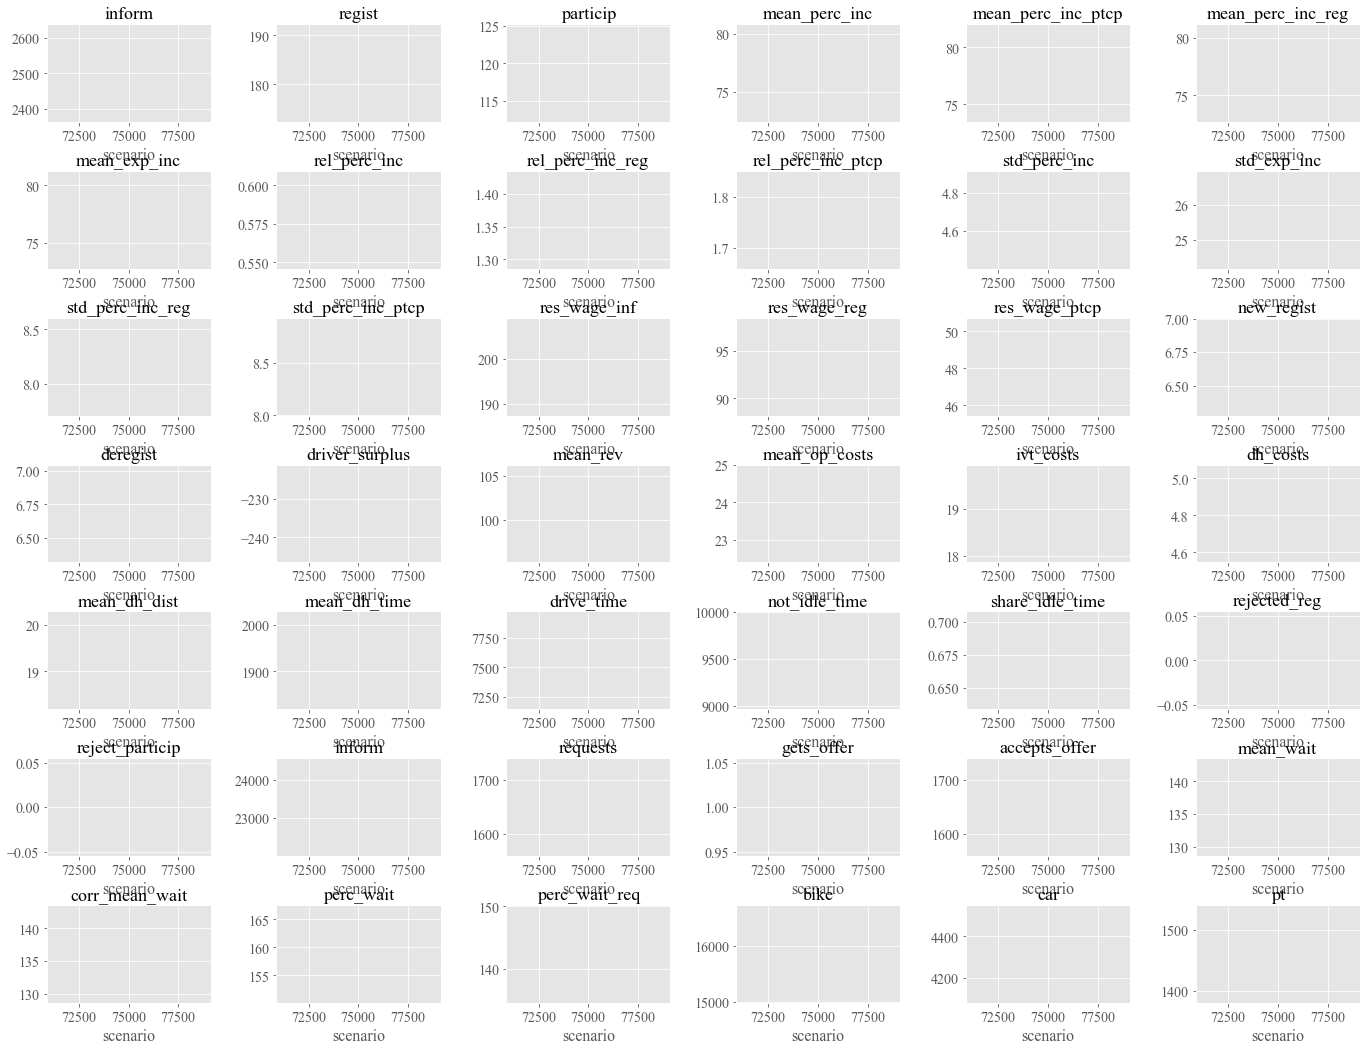

In [50]:
fig, axes = plt.subplots(7, 6, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
i = 0
j = 0

for kpi in kpis_sup:
    axes[j, i] = eql_scn.sup[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = eql_scn.dem[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = eql_scn.plf[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'effect.jpg'),dpi=300,bbox_inches='tight')


In [ ]:
# Plot societal indicators
plt.rc('font', size=18)
plt.rc('xtick', labelsize=18) 
plt.rc('ytick', labelsize=18) 
fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.2, left=.12, right=.88)

axes[0] = (eql_scn.sup.driver_surplus/1000).plot(ax=axes[0])
axes[0].set_title('Driver surplus (x \u20ac1000)')
axes[0].set_xlabel('Gini coefficient')
axes[0].set_xlim([0, 1])
axes[0].axvline(x=0.23,linestyle='--',c='grey')
axes[0].axvline(x=0.64,linestyle='--',c='grey')

axes[1] = (eql_scn.dem.cons_surplus/1000).plot(ax=axes[1])
axes[1].set_title('Consumer surplus (x \u20ac1000)')
axes[1].set_xlabel('Gini coefficient')
axes[1].set_xlim([0, 1])
axes[1].axvline(x=0.23,linestyle='--',c='grey')
axes[1].axvline(x=0.64,linestyle='--',c='grey')

axes[2] = (eql_scn.plf.plat_profit/1000).plot(ax=axes[2])
axes[2].set_title('Platform profit (x \u20ac1000)')
axes[2].set_xlabel('Gini coefficient')
axes[2].set_xlim([0, 1])
axes[2].axvline(x=0.23,linestyle='--',c='grey')
axes[2].axvline(x=0.64,linestyle='--',c='grey')

axes[3] = (eql_scn.soc.soc_value/1000).plot(ax=axes[3])
axes[3].set_title('Societal value (x \u20ac1000)')
axes[3].set_xlabel('Gini coefficient')
axes[3].set_xlim([0, 1])
axes[3].axvline(x=0.23,linestyle='--',c='grey')
axes[3].axvline(x=0.64,linestyle='--',c='grey')

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'societal_value.jpg'),dpi=300,bbox_inches='tight')

In [ ]:
soc_val = pd.DataFrame()
soc_val['driver_surplus'] = eql_scn.sup.driver_surplus
soc_val['cons_surplus'] = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus
soc_val['plat_profit'] = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
ax1 = soc_val.plot()
# ax1.fill_between('driver_surplus', 0, 'plat_profit')

In [ ]:
soc_val = pd.DataFrame()
soc_val['driver_surplus'] = eql_scn.sup.driver_surplus
soc_val['cons_surplus'] = eql_scn.dem.cons_surplus
soc_val['plat_profit'] = eql_scn.plf.plat_profit
ax1 = soc_val.plot()

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.stackplot(soc_val.index, soc_val.cons_surplus, soc_val.plat_profit)
ax.stackplot(soc_val.index, soc_val.driver_surplus)
ax.set_xlabel("Gini")
ax.set_ylabel("Value")
# ax.set_ylim(bottom=-0.5, top=1.5)
# ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)

plt.show()

In [ ]:
requests[50].VoT.max()

In [ ]:
micro.sup.inform[5]

In [ ]:
np.exp(-25)

In [ ]:
np.exp(-100)

In [ ]:
np.exp(-1000)

In [ ]:
np.log(np.exp(-1000))

In [ ]:
res.dem[50]

In [ ]:
micro.dem.wait_time[50]

In [ ]:
ax1 = drivers[50].res_wage.hist(bins=500)
ax1.set_xlim([0, 500])

In [ ]:
ax1 = drivers[55].res_wage.hist(bins=500)
ax1.set_xlim([0, 500])

In [ ]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 1)
    if one_ptcp.any():
        print('run_id {} has day with 1 participant - scenario {}'.format(i,scn.val[i]))
        a += 1
#     if res.sup[i][res.sup[i].particip == 1].shape[0] > 0:
#         print('run_id {} has one day with 1 participant'.format(i))

In [ ]:
conv_repl.head(50)

In [ ]:
res.sup[2]['rejected_reg']

In [ ]:
d2d.sup[2]

In [ ]:
res.sup[0].columns